# Heavy Equipment Selling Price Prediction — ML Project

**Problem type:** Regression (predict `TargetValue`, the resale price of heavy equipment)
**Evaluation metric:** RMSLE (Root Mean Squared Log Error)
**Approach:** EDA → Preprocessing → Feature Engineering → Multi-family Model Building → Hyperparameter Tuning → Model Comparison → Ensemble (Blend) → Error Analysis


## 1. Problem Statement

We are given historical sale records of heavy equipment (bulldozers/construction equipment) with:
- Machine identity/configuration fields (`AssetID`, `ProductConfigID`, `Spec_FullDescriptor`, `Spec_BaseClass`, `Spec_SubClass`, `FunctionalClassification`, `InventoryGroupDescription`)
- Usage/condition fields (`OperationalHoursMeter`, `ManufactureYear`)
- Sale context (`TransactionDate`)

**Goal:** Predict `TargetValue` (sale price) for the test set.

**Why RMSLE?** Prices span several orders of magnitude (cheap used equipment vs. near-new heavy machinery). RMSLE penalizes *relative* error rather than absolute error, and is not dominated by a few very expensive machines. This directly motivates modeling `log1p(TargetValue)` and using RMSE-on-log-target as an equivalent, numerically friendlier training objective — which is what the modeling section below does.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

TRAIN_PATH = '/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv'
TEST_PATH  = '/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv'

train = pd.read_csv(TRAIN_PATH, low_memory=False)
test  = pd.read_csv(TEST_PATH, low_memory=False)

print("Train shape:", train.shape)
print("Test shape :", test.shape)


Train shape: (138701, 50)
Test shape : (15000, 49)


In [2]:
train.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [3]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [4]:
train.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,138701.0,NaN,NaN,NaN,2186275.950556,1128496.619347,1139309.0,1465754.0,1751884.0,2372139.0,6333410.0
TargetValue,138701.0,NaN,NaN,NaN,41521.874047,26361.125948,7500.0,20500.0,35000.0,57000.0,142000.0
AssetID,138701.0,NaN,NaN,NaN,1204814.320423,528737.593449,8.0,1007930.0,1246956.0,1495817.0,2478476.0
ProductConfigID,138701.0,NaN,NaN,NaN,7286.421922,7542.421537,39.0,1693.0,3852.0,11873.0,37209.0
DataOriginCode,138701,6,ADI149,59541,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VendorPartnerID,138701,31,UJF,67828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ManufactureYear,138701.0,NaN,NaN,NaN,1891.640853,306.992001,1001.0,1990.0,1998.0,2004.0,2015.0
OperationalHoursMeter,82058.0,NaN,NaN,NaN,4553.718943,27922.04485,0.0,0.0,1620.0,5001.0,1729600.0
UtilizationTier,50475,3,Medium,24588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionDate,138701,3676,2010-02-16,1159,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Exploratory Data Analysis (EDA)

**Objective:** Understand the distribution of the target, the quality of the features (missingness, cardinality), and how individual features relate to `TargetValue`. Every insight found here is used to justify a preprocessing or feature-engineering decision later.


### 2.1 Univariate Analysis — Target Variable

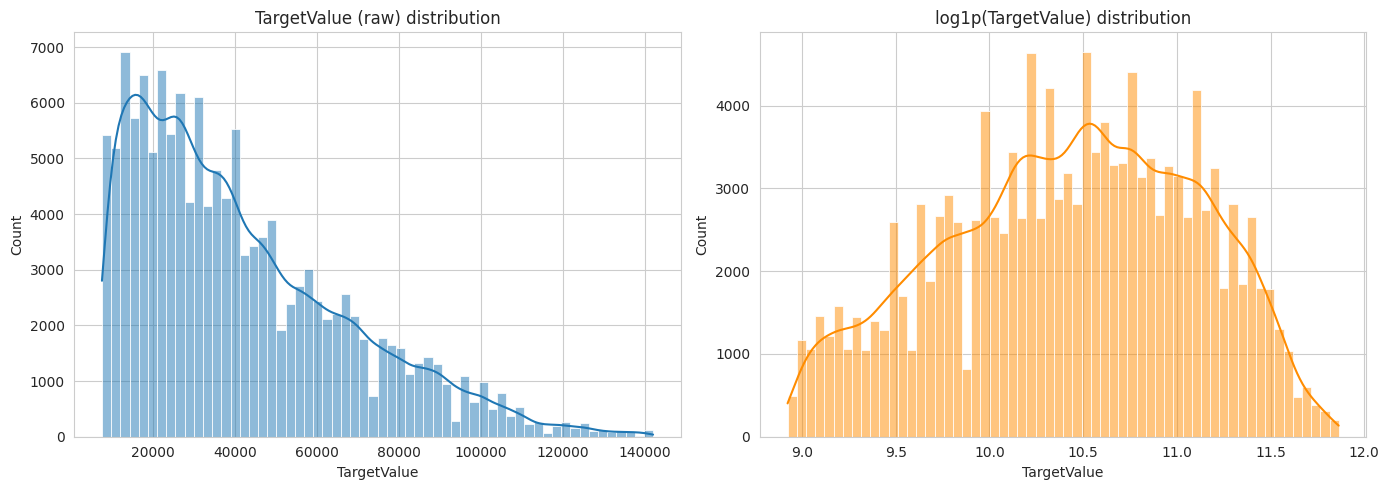

Raw skew: 0.97
Log1p skew: -0.2


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train['TargetValue'], bins=60, kde=True, ax=ax[0])
ax[0].set_title('TargetValue (raw) distribution')

sns.histplot(np.log1p(train['TargetValue']), bins=60, kde=True, ax=ax[1], color='darkorange')
ax[1].set_title('log1p(TargetValue) distribution')
plt.tight_layout()
plt.show()

print("Raw skew:", train['TargetValue'].skew().round(2))
print("Log1p skew:", np.log1p(train['TargetValue']).skew().round(2))


**Insight:** The raw target is heavily right-skewed (long tail of expensive machines). After `log1p`, the distribution is far closer to symmetric/normal.
**Decision:** Train all models on `log1p(TargetValue)` and invert with `expm1` at prediction time. This stabilizes variance, is consistent with optimizing RMSLE via RMSE-on-log-target, and prevents a small number of expensive machines from dominating the loss.


### 2.2 Missing Value Analysis

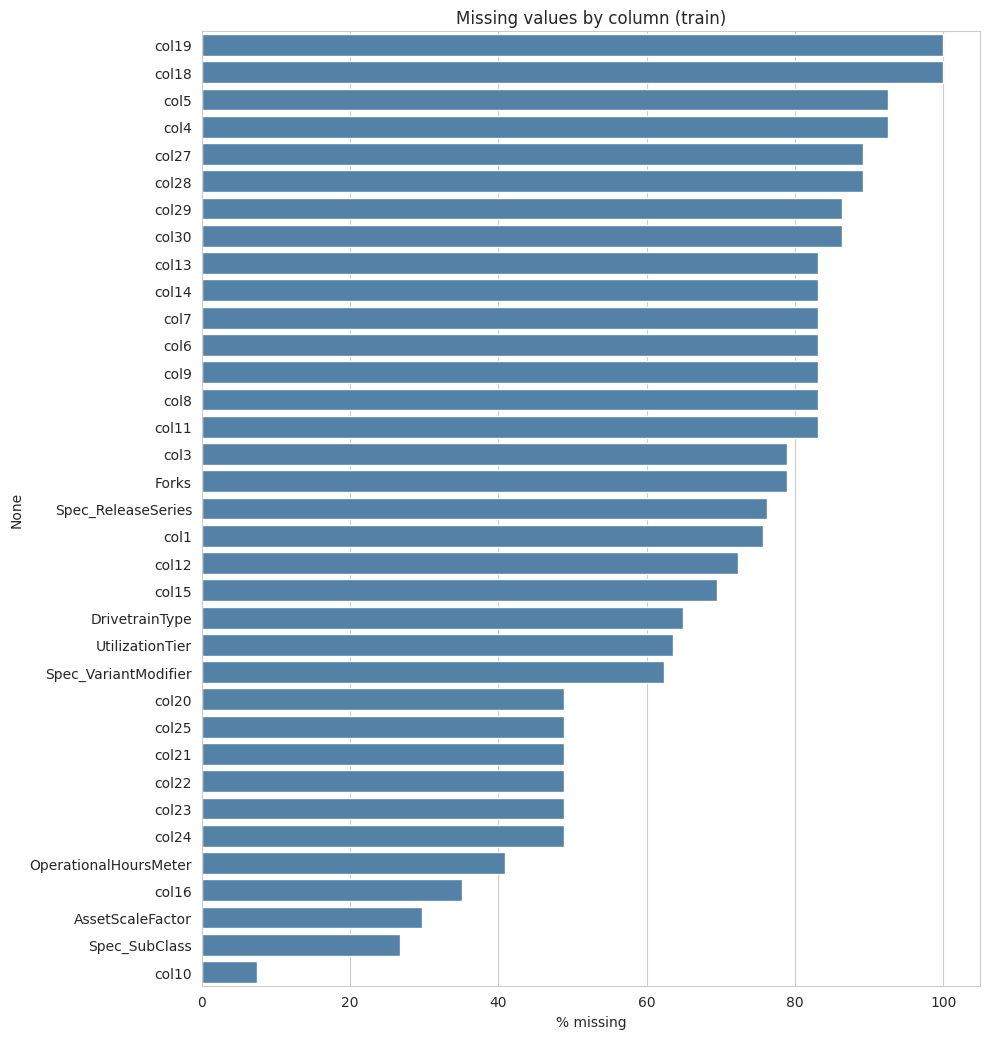

col19                    99.952416
col18                    99.952416
col5                     92.515555
col4                     92.515555
col27                    89.214930
col28                    89.214930
col29                    86.393753
col30                    86.393753
col13                    83.125572
col14                    83.125572
col7                     83.125572
col6                     83.125572
col9                     83.125572
col8                     83.125572
col11                    83.125572
col3                     78.909309
Forks                    78.861724
Spec_ReleaseSeries       76.282795
col1                     75.641127
col12                    72.340502
col15                    69.519326
DrivetrainType           64.856057
UtilizationTier          63.608770
Spec_VariantModifier     62.269919
col20                    48.799216
col25                    48.799216
col21                    48.799216
col22                    48.797774
col23               

In [6]:
missing = train.isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

plt.figure(figsize=(10, max(4, 0.3*len(missing))))
sns.barplot(x=missing.values, y=missing.index, color='steelblue')
plt.xlabel('% missing')
plt.title('Missing values by column (train)')
plt.tight_layout()
plt.show()

missing


**Insight:** Missingness is concentrated in a subset of columns (typically usage/condition fields like `OperationalHoursMeter` and `ManufactureYear`, which can be legitimately unrecorded for older sales). This is **not** uniformly random across rows, so a single blanket `dropna()` would discard usable rows.
**Decision:** Missingness is handled column-by-column in the Preprocessing section — numeric columns get median/indicator imputation, categorical columns get an explicit `'MISSING'` category (which tree models can split on and treat as informative), rather than deletion.


### 2.3 Numerical Feature Distributions

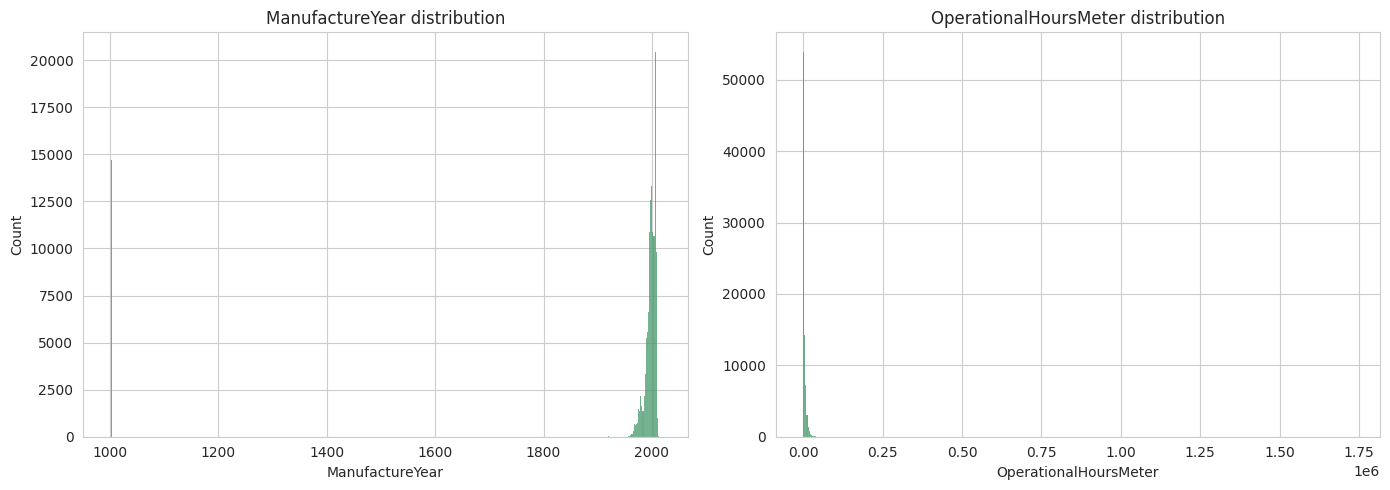

In [7]:
num_candidates = ['ManufactureYear', 'OperationalHoursMeter']
num_candidates = [c for c in num_candidates if c in train.columns]

fig, axes = plt.subplots(1, len(num_candidates), figsize=(7*len(num_candidates), 5))
if len(num_candidates) == 1:
    axes = [axes]
for ax, col in zip(axes, num_candidates):
    sns.histplot(train[col].dropna(), bins=500, ax=ax, color='seagreen')
    ax.set_title(f'{col} distribution')
plt.tight_layout()
plt.show()


**Insight:** `ManufactureYear` contains implausible placeholder values (e.g. year 1000/0) used by data entry systems to mean "unknown" — these are not real years and must be masked to NaN before any age-based feature is derived (this is why the original feature-engineering code applies `full.loc[full['ManufactureYear'] < 1900, 'ManufactureYear'] = np.nan`). `OperationalHoursMeter` similarly has a spike at 0, which typically means "not recorded" rather than a genuinely zero-hour machine, and is masked the same way.


### 2.4 Categorical Feature Cardinality

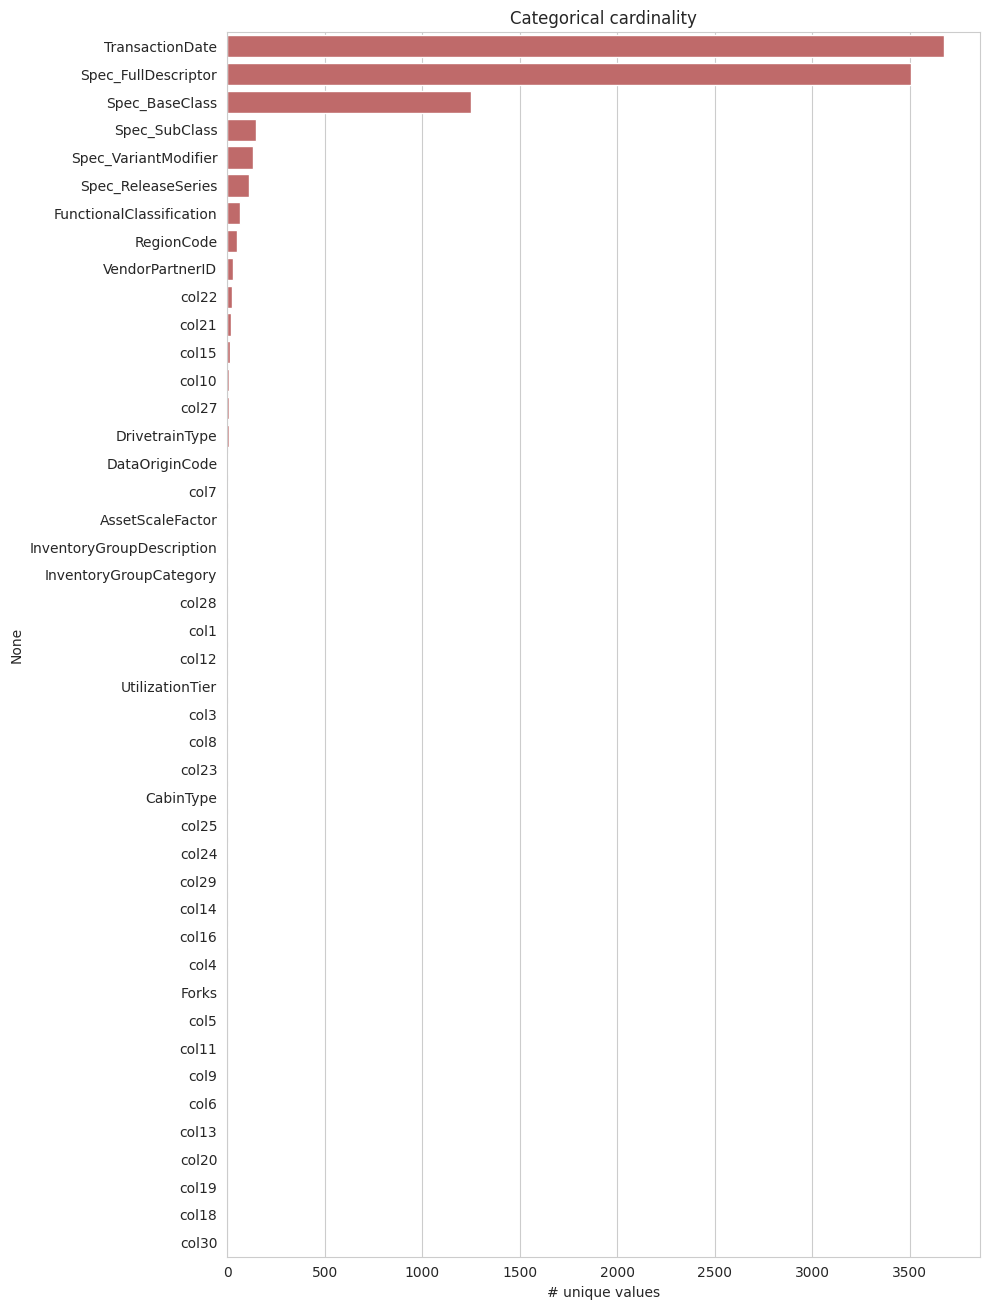

TransactionDate              3676
Spec_FullDescriptor          3505
Spec_BaseClass               1249
Spec_SubClass                 147
Spec_VariantModifier          132
Spec_ReleaseSeries            113
FunctionalClassification       65
RegionCode                     53
VendorPartnerID                31
col22                          27
col21                          18
col15                          15
col10                          11
col27                           9
DrivetrainType                  8
DataOriginCode                  6
col7                            6
AssetScaleFactor                6
InventoryGroupDescription       6
InventoryGroupCategory          6
col28                           5
col1                            4
col12                           4
UtilizationTier                 3
col3                            3
col8                            3
col23                           3
CabinType                       3
col25                           3
col24         

In [8]:
cat_cols_eda = [c for c in train.columns if train[c].dtype == object]
card = train[cat_cols_eda].nunique().sort_values(ascending=False)

plt.figure(figsize=(10, max(4, 0.3*len(card))))
sns.barplot(x=card.values, y=card.index, color='indianred')
plt.xlabel('# unique values')
plt.title('Categorical cardinality')
plt.tight_layout()
plt.show()

card


**Insight:** Some categorical columns (e.g. `AssetID`, `Spec_FullDescriptor`, `ProductConfigID`) are very high-cardinality — essentially near-identifiers. One-hot encoding these would explode dimensionality and is inappropriate.
**Decision:** High-cardinality categoricals are handled with **frequency encoding** and **K-Fold target encoding** (leak-safe) instead of one-hot encoding; low-cardinality categoricals are handled natively by tree-based models or one-hot encoded for the linear baseline. This is implemented explicitly in the Preprocessing/Feature Engineering sections.


### 2.5 Bivariate Analysis — Numeric Features vs Target

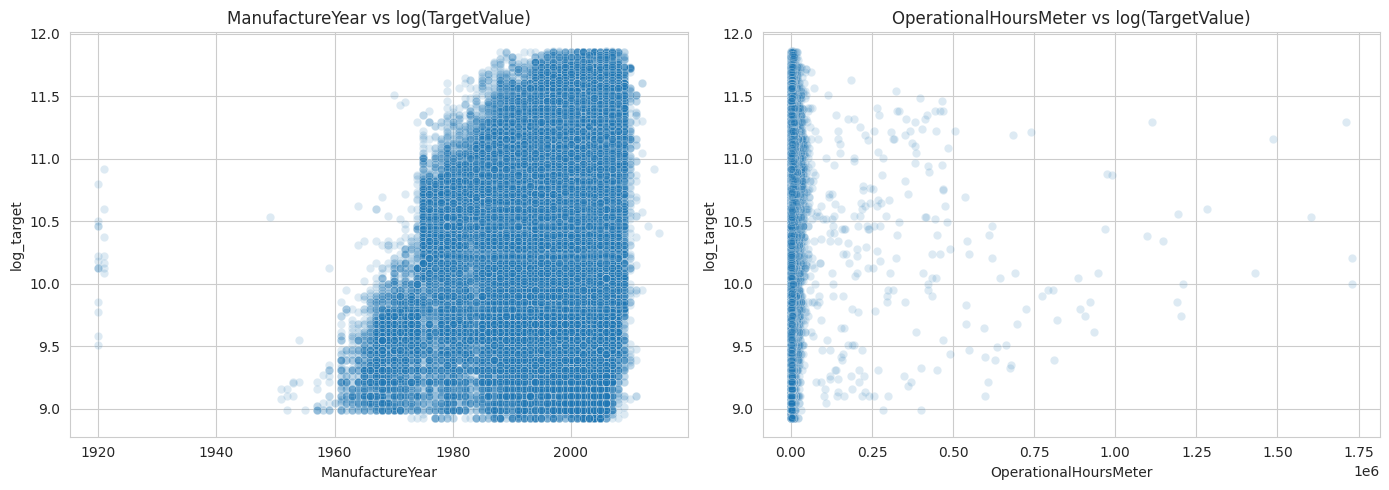

In [9]:
eda = train.copy()
eda['log_target'] = np.log1p(eda['TargetValue'])
eda.loc[eda['ManufactureYear'] < 1900, 'ManufactureYear'] = np.nan
eda.loc[eda['OperationalHoursMeter'] == 0, 'OperationalHoursMeter'] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x='ManufactureYear', y='log_target', data=eda, alpha=0.15, ax=axes[0])
axes[0].set_title('ManufactureYear vs log(TargetValue)')

sns.scatterplot(x='OperationalHoursMeter', y='log_target', data=eda, alpha=0.15, ax=axes[1])
axes[1].set_title('OperationalHoursMeter vs log(TargetValue)')
plt.tight_layout()
plt.show()


**Insight:** Newer manufacture years trend toward higher price (less depreciation), and higher operational hours trend toward lower price (more wear) — both consistent with domain intuition. Neither relationship is perfectly linear, which supports using non-linear tree-based models as the primary model family rather than relying on a linear model alone.


### 2.6 Bivariate Analysis — Categorical Features vs Target

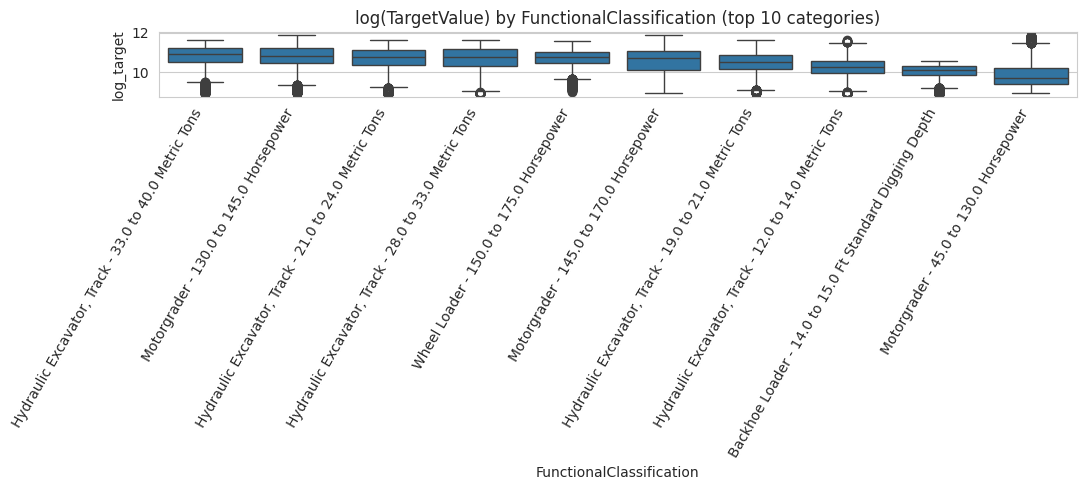

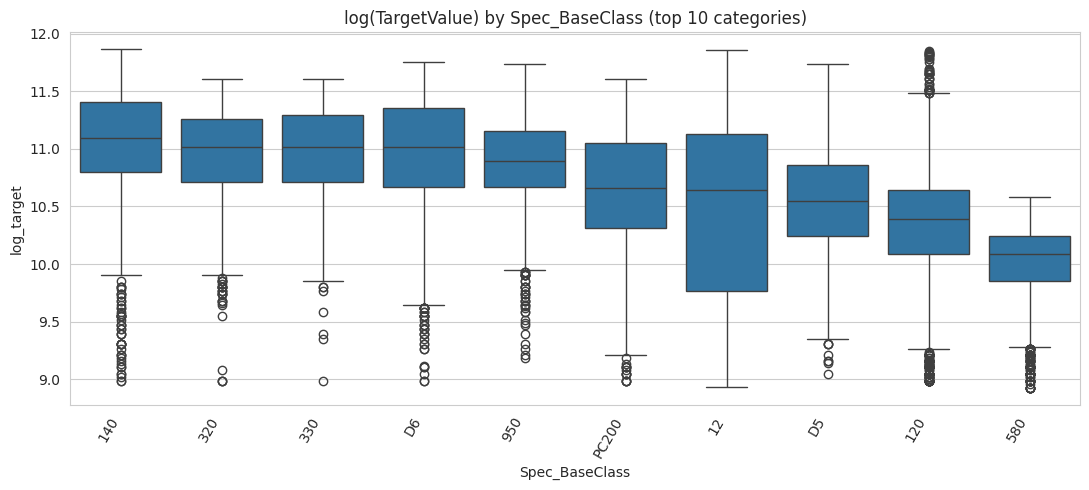

In [10]:
cat_for_box = [c for c in ['FunctionalClassification', 'Spec_BaseClass'] if c in eda.columns]

for col in cat_for_box:
    top_cats = eda[col].value_counts().nlargest(10).index
    subset = eda[eda[col].isin(top_cats)]
    plt.figure(figsize=(11, 5))
    order = subset.groupby(col)['log_target'].median().sort_values(ascending=False).index
    sns.boxplot(x=col, y='log_target', data=subset, order=order)
    plt.xticks(rotation=60, ha='right')
    plt.title(f'log(TargetValue) by {col} (top 10 categories)')
    plt.tight_layout()
    plt.show()

**Insight:** Median price varies substantially across categories within `FunctionalClassification` / `Spec_BaseClass`, confirming these are informative predictors. This motivates including a target-encoded version of these columns as a feature (captures the price-level signal per category directly) in addition to their raw categorical form.


### 2.7 Price Trend Over Time

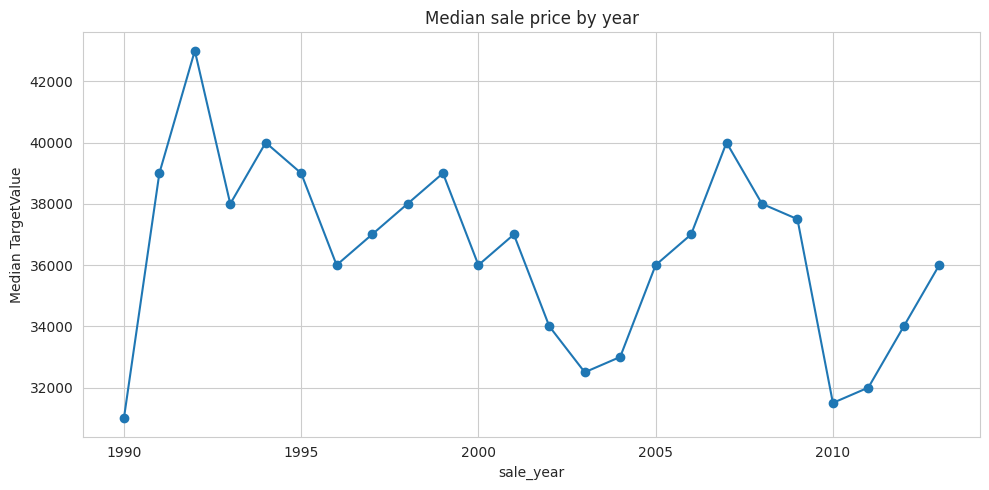

In [11]:
eda['TransactionDate'] = pd.to_datetime(eda['TransactionDate'], errors='coerce')
eda['sale_year'] = eda['TransactionDate'].dt.year

yearly = eda.groupby('sale_year')['TargetValue'].median()
plt.figure(figsize=(10, 5))
yearly.plot(marker='o')
plt.ylabel('Median TargetValue')
plt.title('Median sale price by year')
plt.tight_layout()
plt.show()


**Insight:** Median prices shift over time (inflation, market cycles, product-mix changes across years). This justifies engineering explicit date-derived features (`sale_year`, `sale_month`, `sale_elapsed`, cyclical month encoding) rather than dropping the date column.


## 3. Preprocessing

Guided directly by the EDA above, preprocessing must:
1. Mask sentinel/placeholder values (`ManufactureYear < 1900`, `OperationalHoursMeter == 0`) as missing.
2. Impute remaining missing values — numeric columns via median (robust to outliers), categorical columns via an explicit `'MISSING'` category.
3. Scale numeric features for the **linear baseline model only** (tree models are scale-invariant, so scaling is skipped for LightGBM/XGBoost to avoid unnecessary transformation).
4. Encode categorical features appropriately by cardinality (native categorical support for trees, frequency/target encoding for high-cardinality columns, one-hot for the linear baseline's low-cardinality columns).

All of this is implemented as **reusable functions** applied identically to train and test to avoid data leakage and code duplication.


In [12]:
def mask_sentinel_values(df):
    """Replace known placeholder/sentinel values with NaN so they are handled
    by imputation instead of being treated as real measurements."""
    df = df.copy()
    if 'ManufactureYear' in df.columns:
        df.loc[df['ManufactureYear'] < 1900, 'ManufactureYear'] = np.nan
    if 'OperationalHoursMeter' in df.columns:
        df.loc[df['OperationalHoursMeter'] == 0, 'OperationalHoursMeter'] = np.nan
    return df


def report_missing(df, name=''):
    m = df.isna().mean().sort_values(ascending=False)
    m = m[m > 0]
    print(f"--- Missing value report: {name} ---")
    print((m * 100).round(2).astype(str) + '%' if len(m) else 'No missing values')
    return m


def impute_missing(df, numeric_cols, categorical_cols, fill_values=None):
    """Reusable imputation: median for numeric (computed on TRAIN only and
    passed in via fill_values to avoid leakage), explicit 'MISSING' token for
    categorical columns."""
    df = df.copy()
    fill_values = fill_values or {}
    for col in numeric_cols:
        if col in df.columns:
            fill_val = fill_values.get(col, df[col].median())
            df[col] = df[col].fillna(fill_val)
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).fillna('MISSING').replace('nan', 'MISSING')
    return df


In [13]:
train_masked = mask_sentinel_values(train)
test_masked  = mask_sentinel_values(test)

_ = report_missing(train_masked, 'train (post sentinel-masking)')


--- Missing value report: train (post sentinel-masking) ---
col19                    99.95%
col18                    99.95%
col5                     92.52%
col4                     92.52%
col27                    89.21%
col28                    89.21%
col29                    86.39%
col30                    86.39%
col13                    83.13%
col14                    83.13%
col7                     83.13%
col6                     83.13%
col9                     83.13%
col8                     83.13%
col11                    83.13%
col3                     78.91%
Forks                    78.86%
Spec_ReleaseSeries       76.28%
col1                     75.64%
col12                    72.34%
col15                    69.52%
DrivetrainType           64.86%
UtilizationTier          63.61%
OperationalHoursMeter    63.61%
Spec_VariantModifier     62.27%
col25                     48.8%
col20                     48.8%
col21                     48.8%
col22                     48.8%
col24       

### 3.1 Scaling (for the linear baseline)

Tree-based models (LightGBM/XGBoost) split on raw feature values and are invariant to monotonic transforms like scaling, so scaling is **not** applied before them. It **is** required for the Ridge/Linear baseline, since regularized linear models are sensitive to feature magnitude. This is implemented with a `StandardScaler` fit on train only and applied to test — no leakage.


In [14]:
from sklearn.preprocessing import StandardScaler

def fit_scaler(train_df, numeric_cols):
    scaler = StandardScaler()
    scaler.fit(train_df[numeric_cols])
    return scaler

def apply_scaler(df, numeric_cols, scaler):
    df = df.copy()
    df[numeric_cols] = scaler.transform(df[numeric_cols])
    return df


### 3.2 Encoding

- **Tree models:** native categorical handling (LightGBM `categorical_feature`) or integer codes (XGBoost).
- **High-cardinality columns** (`AssetID`, `Spec_FullDescriptor`, `ProductConfigID`, and engineered combinations): **frequency encoding** (counted across train+test combined — safe, since it never touches the target, only how often an ID/value recurs across the whole dataset) + **K-Fold target encoding** (leak-safe, computed only from the training folds, since this one *does* use the target).
- **Linear baseline:** one-hot encoding of low-cardinality categoricals, target/frequency encoding reused for the high-cardinality ones.

The K-Fold target-encoding function below is written once and reused for every column that needs it — this is the reusable-pipeline requirement in practice; it is called again in the Feature Engineering section on the engineered interaction columns.


In [15]:
from sklearn.model_selection import KFold

def kfold_target_encode(train_df, test_df, col, target, n_splits=5, seed=1, smoothing_k=10, smoothing_f=5):
    """Leak-safe K-Fold target encoding with sigmoid smoothing toward the
    global mean for low-count categories. Reusable for any column."""
    oof = np.zeros(len(train_df))
    global_mean = target.mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    tmp = train_df[[col]].copy()
    tmp['__y__'] = target.values

    for tr_idx, val_idx in kf.split(tmp):
        means = tmp.iloc[tr_idx].groupby(col)['__y__'].mean()
        counts = tmp.iloc[tr_idx].groupby(col)['__y__'].count()
        smoothing = 1 / (1 + np.exp(-(counts - smoothing_k) / smoothing_f))
        smoothed = global_mean * (1 - smoothing) + means * smoothing
        oof[val_idx] = tmp.iloc[val_idx][col].map(smoothed).fillna(global_mean).values

    full_means = tmp.groupby(col)['__y__'].mean()
    full_counts = tmp.groupby(col)['__y__'].count()
    smoothing = 1 / (1 + np.exp(-(full_counts - smoothing_k) / smoothing_f))
    smoothed_full = global_mean * (1 - smoothing) + full_means * smoothing
    test_enc = test_df[col].map(smoothed_full).fillna(global_mean).values

    return oof, test_enc


def frequency_encode(train_df, test_df, col):
    """Frequency computed over TRAIN+TEST combined (transductive). This is
    safe -- it never touches the target, only how often an ID/spec value
    appears across the full dataset -- and matters a lot for near-identifier
    columns like AssetID that recur across train and test."""
    combined = pd.concat([train_df[col], test_df[col]], axis=0)
    freq = combined.value_counts()
    train_enc = train_df[col].map(freq).fillna(0).values
    test_enc = test_df[col].map(freq).fillna(0).values
    return train_enc, test_enc


## 4. Feature Engineering

Each engineered feature below is directly motivated by an EDA insight:

| Feature | Motivated by |
|---|---|
| `sale_year`, `sale_month`, `sale_elapsed`, cyclical month sin/cos | §2.7 price trend over time |
| `AssetAge` = sale_year − ManufactureYear | §2.5 ManufactureYear vs price relationship |
| `HoursPerYear`, `log_hours` | §2.5 OperationalHoursMeter vs price relationship |
| `SpecDescriptor_num/len`, `FunctionalClass_mid`, `InventoryDesc_len` | text/spec fields encode numeric machine specs as strings |
| `*_freq` frequency encodings | §2.4 high-cardinality categoricals |
| `*_te` K-Fold target encodings | §2.6 category-level price differences |
| `BaseSub`, `ConfigFunc` interaction columns | capture combined effect of two related categorical fields |


In [16]:
def engineer_features(df):
    """Pure feature engineering — no leakage-sensitive statistics computed
    here (those are done separately via kfold_target_encode/frequency_encode)."""
    df = df.copy()
    df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')
    df['sale_year'] = df['TransactionDate'].dt.year
    df['sale_month'] = df['TransactionDate'].dt.month
    df['sale_day'] = df['TransactionDate'].dt.day
    df['sale_dayofweek'] = df['TransactionDate'].dt.dayofweek
    df['sale_dayofyear'] = df['TransactionDate'].dt.dayofyear
    df['sale_elapsed'] = (df['TransactionDate'] - df['TransactionDate'].min()).dt.days
    df['sale_month_sin'] = np.sin(2*np.pi*df['sale_month']/12)
    df['sale_month_cos'] = np.cos(2*np.pi*df['sale_month']/12)

    df['AssetAge'] = df['sale_year'] - df['ManufactureYear']
    df.loc[df['AssetAge'] < 0, 'AssetAge'] = np.nan

    df['HoursPerYear'] = df['OperationalHoursMeter'] / (df['AssetAge'] + 1)
    df['log_hours'] = np.log1p(df['OperationalHoursMeter'])

    def extract_numeric(s):
        if pd.isna(s):
            return np.nan
        m = re.search(r'(\d+\.?\d*)', str(s))
        return float(m.group(1)) if m else np.nan

    def extract_range_mid(s):
        if pd.isna(s):
            return np.nan
        nums = [float(n) for n in re.findall(r'(\d+\.?\d*)', str(s))]
        if len(nums) >= 2:
            return (nums[0] + nums[1]) / 2
        elif len(nums) == 1:
            return nums[0]
        return np.nan

    df['SpecDescriptor_num'] = df['Spec_FullDescriptor'].apply(extract_numeric)
    df['SpecDescriptor_len'] = df['Spec_FullDescriptor'].astype(str).apply(len)
    df['FunctionalClass_mid'] = df['FunctionalClassification'].apply(extract_range_mid)
    df['InventoryDesc_len'] = df['InventoryGroupDescription'].astype(str).apply(len)

    df['BaseSub'] = df['Spec_BaseClass'].astype(str) + '_' + df['Spec_SubClass'].astype(str)
    df['ConfigFunc'] = df['ProductConfigID'].astype(str) + '_' + df['FunctionalClassification'].astype(str)

    return df

y_all = np.log1p(train['TargetValue'].values)
train_ids = train['TransactionID'].values
test_ids = test['TransactionID'].values

train_masked = mask_sentinel_values(train.drop(columns=['TargetValue']))
test_masked  = mask_sentinel_values(test)

train_fe = engineer_features(train_masked)
test_fe  = engineer_features(test_masked)

# AssetID sale-count feature computed the same way for train and test to avoid
# mismatched scales at inference time
full_ids = pd.concat([train_fe['AssetID'], test_fe['AssetID']], axis=0)
id_counts = full_ids.value_counts()
train_fe['AssetID_sale_count'] = train_fe['AssetID'].map(id_counts)
test_fe['AssetID_sale_count']  = test_fe['AssetID'].map(id_counts)

print("Train FE shape:", train_fe.shape, " Test FE shape:", test_fe.shape)
train_fe.head()


Train FE shape: (138701, 67)  Test FE shape: (15000, 67)


,TransactionID,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,...,AssetAge,HoursPerYear,log_hours,SpecDescriptor_num,SpecDescriptor_len,FunctionalClass_mid,InventoryDesc_len,BaseSub,ConfigFunc,AssetID_sale_count
0,1139309,117665,88,ACH138,GTX,1997.0,4640.0,Low,2005-03-26,950FII,...,8.0,515.555556,8.442685,950.0,6,162.5,12,950_F,88_Wheel Loader - 150.0 to 175.0 Horsepower,1
1,1139316,1001282,4616,ACH138,GTX,2005.0,508.0,Low,2009-12-18,310G,...,4.0,101.600000,6.232448,310.0,4,14.5,15,310_G,4616_Backhoe Loader - 14.0 to 15.0 Ft Standard...,1
2,1139317,772709,1948,ACH138,GTX,1994.0,11540.0,High,2005-08-26,790ELC,...,11.0,961.666667,9.353661,790.0,6,22.5,16,790_E,"1948_Hydraulic Excavator, Track - 21.0 to 24.0...",2
3,1139322,902010,3550,ACH138,GTX,2002.0,4883.0,High,2006-11-17,416D,...,4.0,976.600000,8.493720,416.0,4,14.5,15,416_D,3550_Backhoe Loader - 14.0 to 15.0 Ft Standard...,1
4,1139333,1036259,36014,ACH138,GTX,2009.0,302.0,Low,2010-08-27,430HAG,...,1.0,151.000000,5.713733,430.0,6,3.5,16,430_HAG,"36014_Hydraulic Excavator, Track - 3.0 to 4.0 ...",1


In [17]:
te_cols = ['ProductConfigID', 'Spec_FullDescriptor', 'FunctionalClassification',
           'BaseSub', 'ConfigFunc', 'AssetID']
freq_cols = ['AssetID', 'ProductConfigID', 'Spec_FullDescriptor']

y_series = pd.Series(y_all)

for col in te_cols:
    oof_enc, test_enc = kfold_target_encode(train_fe, test_fe, col, y_series)
    train_fe[col + '_te'] = oof_enc
    test_fe[col + '_te'] = test_enc

for col in freq_cols:
    tr_enc, te_enc = frequency_encode(train_fe, test_fe, col)
    train_fe[col + '_freq'] = tr_enc
    test_fe[col + '_freq'] = te_enc

print("Feature engineering complete.")
print("Final train feature count:", train_fe.shape[1])


Feature engineering complete.
Final train feature count: 76


**Note on feature importance:** rather than eyeballing engineered features in isolation, their importance is assessed empirically after model training (Section 7) via LightGBM's split-gain importances — this is more reliable than judging a feature's usefulness before any model has actually used it.


## 5. Model Building

Seven models are built and compared, in three stages. Jump to any of them directly:

- **Model 1: Ridge Regression** (§5.1) — linear baseline
- **Model 2: LightGBM** (§5.2) — gradient-boosted trees, native categorical/missing-value handling
- **Model 3: XGBoost** (§5.3) — gradient-boosted trees, integer-coded categoricals
- **§5.4 Hyperparameter Tuning** — search for better parameters for Models 1-3
- **Model 4: Ridge (Tuned)** (§5.5)
- **Model 5: LightGBM (Tuned)**
- **Model 6: XGBoost (Tuned)**
- **Model 7: Ensemble** (§5.6) — a fixed blend of Model 5 (LightGBM Tuned) + Model 6 (XGBoost Tuned), weight chosen via a weight search on OOF predictions. This ensemble is selected as the **final model** (§8).

All seven are evaluated with the same 5-fold `KFold` split and the same metric (RMSLE, computed on `expm1`-inverted predictions), so the comparison in Section 6 and the final selection in Section 8 are apples-to-apples. Section 8 uses this ensemble as the final model directly; the other six are shown alongside it purely for comparison, not for automatic selection.OF RMSLE.


In [18]:
def rmsle(y_true_log, y_pred_log):
    """Both inputs already in log1p space -> RMSLE == RMSE in this space."""
    return np.sqrt(np.mean((y_true_log - y_pred_log) ** 2))

NFOLDS = 5
kf = KFold(n_splits=NFOLDS, shuffle=True, random_state=42)


### 5.1 Model 1: Ridge Regression (Linear Baseline)

A simple, fully linear model. Categorical columns are one-hot encoded (low-cardinality only — the same high-cardinality columns identified in §2.4 are instead represented via their frequency/target encodings, since one-hot encoding them would be computationally infeasible and statistically noisy for a linear model).


In [19]:
from sklearn.linear_model import Ridge
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

numeric_for_linear = ['ManufactureYear', 'OperationalHoursMeter', 'AssetAge', 'HoursPerYear',
                       'log_hours', 'SpecDescriptor_num', 'SpecDescriptor_len', 'FunctionalClass_mid',
                       'InventoryDesc_len', 'sale_year', 'sale_month', 'sale_elapsed',
                       'sale_month_sin', 'sale_month_cos', 'AssetID_sale_count'] + \
                      [c + '_te' for c in te_cols] + [c + '_freq' for c in freq_cols]
numeric_for_linear = [c for c in numeric_for_linear if c in train_fe.columns]

low_card_cats = [c for c in train_fe.columns
                  if train_fe[c].dtype == object and train_fe[c].nunique() <= 30]

linear_features = numeric_for_linear + low_card_cats

X_lin = impute_missing(train_fe[linear_features], numeric_for_linear, low_card_cats)
X_lin_test = impute_missing(test_fe[linear_features], numeric_for_linear, low_card_cats)

preprocess_linear = ColumnTransformer([
    ('num', StandardScaler(), numeric_for_linear),
    ('cat', OneHotEncoder(handle_unknown='ignore'), low_card_cats),
])

ridge_pipe = Pipeline([
    ('prep', preprocess_linear),
    ('model', Ridge(alpha=5.0)),
])

oof_ridge = np.zeros(len(X_lin))
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_lin)):
    ridge_pipe.fit(X_lin.iloc[tr_idx], y_all[tr_idx])
    oof_ridge[val_idx] = ridge_pipe.predict(X_lin.iloc[val_idx])

ridge_rmsle = rmsle(y_all, oof_ridge)
print(f"Ridge baseline OOF RMSLE: {ridge_rmsle:.5f}")

ridge_pipe.fit(X_lin, y_all)
test_ridge = ridge_pipe.predict(X_lin_test)


Ridge baseline OOF RMSLE: 0.31190


### 5.2 / 5.3 Shared Preprocessing for Model 2 (LightGBM) and Model 3 (XGBoost)

Full implementations with 5-fold CV and early stopping. (This reuses your original modeling code, now sitting on top of the reusable preprocessing/feature-engineering functions above instead of ad-hoc inline steps.) LightGBM uses native categorical handling; XGBoost uses integer-coded categoricals, since it does not support raw categorical columns the same way.


In [20]:
import lightgbm as lgb
import xgboost as xgb

drop_cols = ['TransactionID', 'TransactionDate']
cat_cols = [c for c in train_fe.columns if train_fe[c].dtype == object and c not in drop_cols]
for c in ['AssetID', 'ProductConfigID']:
    if c not in cat_cols and c in train_fe.columns:
        cat_cols.append(c)

full_fe = pd.concat([train_fe, test_fe], axis=0, ignore_index=True)
for col in cat_cols:
    full_fe[col] = full_fe[col].astype(str).fillna('MISSING').astype('category')

n_train = len(train_fe)
feature_cols_lgb = [c for c in full_fe.columns if c not in drop_cols]
X_full_lgb = full_fe[feature_cols_lgb]
X_train_lgb = X_full_lgb.iloc[:n_train].reset_index(drop=True)
X_test_lgb = X_full_lgb.iloc[n_train:].reset_index(drop=True)
cat_feature_idx = [X_train_lgb.columns.get_loc(c) for c in cat_cols if c in X_train_lgb.columns]

full_xgb = full_fe.copy()
for col in cat_cols:
    full_xgb[col + '_code'] = full_xgb[col].cat.codes
feature_cols_xgb = [c for c in full_xgb.columns if c not in drop_cols and c not in cat_cols]
X_full_xgb = full_xgb[feature_cols_xgb]
X_train_xgb = X_full_xgb.iloc[:n_train].reset_index(drop=True)
X_test_xgb = X_full_xgb.iloc[n_train:].reset_index(drop=True)

print("LGB features:", len(feature_cols_lgb), " XGB features:", len(feature_cols_xgb))


LGB features: 74  XGB features: 74


### Model 2: LightGBM


In [21]:
# ---------------- LightGBM 5-fold ----------------
oof_lgb = np.zeros(n_train)
test_lgb = np.zeros(len(X_test_lgb))
lgb_fold_scores = []

lgb_params = {
    'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.05,
    'num_leaves': 511, 'max_depth': -1, 'min_data_in_leaf': 15,
    'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 1,
    'lambda_l1': 0.1, 'lambda_l2': 0.1, 'verbosity': -1, 'num_threads': 4,
}

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_lgb)):
    X_tr, X_val = X_train_lgb.iloc[tr_idx], X_train_lgb.iloc[val_idx]
    y_tr, y_val = y_all[tr_idx], y_all[val_idx]
    dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_feature_idx)
    dval = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_feature_idx, reference=dtrain)
    model = lgb.train(lgb_params, dtrain, num_boost_round=3000, valid_sets=[dval],
                       callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
    oof_lgb[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    test_lgb += model.predict(X_test_lgb, num_iteration=model.best_iteration) / NFOLDS
    fold_rmse = rmsle(y_val, oof_lgb[val_idx])
    lgb_fold_scores.append(fold_rmse)
    print(f"LGB fold {fold+1} RMSLE: {fold_rmse:.5f}")

lgb_rmsle = rmsle(y_all, oof_lgb)
print(f"LightGBM overall OOF RMSLE: {lgb_rmsle:.5f}")
lgb_model_last = model  # keep for feature importance plot


LGB fold 1 RMSLE: 0.19660
LGB fold 2 RMSLE: 0.19823
LGB fold 3 RMSLE: 0.19958
LGB fold 4 RMSLE: 0.19992
LGB fold 5 RMSLE: 0.19781
LightGBM overall OOF RMSLE: 0.19843


### Model 3: XGBoost


In [22]:
# ---------------- XGBoost 5-fold ----------------
oof_xgb = np.zeros(n_train)
test_xgb = np.zeros(len(X_test_xgb))
xgb_fold_scores = []

xgb_params = {
    'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'eta': 0.05,
    'max_depth': 10, 'subsample': 0.8, 'colsample_bytree': 0.8,
    'min_child_weight': 5, 'tree_method': 'hist', 'nthread': 4,
}

dtest_xgb = xgb.DMatrix(X_test_xgb)
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_xgb)):
    X_tr, X_val = X_train_xgb.iloc[tr_idx], X_train_xgb.iloc[val_idx]
    y_tr, y_val = y_all[tr_idx], y_all[val_idx]
    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    dval = xgb.DMatrix(X_val, label=y_val)
    model = xgb.train(xgb_params, dtrain, num_boost_round=2000, evals=[(dval, 'val')],
                       early_stopping_rounds=50, verbose_eval=False)
    oof_xgb[val_idx] = model.predict(xgb.DMatrix(X_val), iteration_range=(0, model.best_iteration+1))
    test_xgb += model.predict(dtest_xgb, iteration_range=(0, model.best_iteration+1)) / NFOLDS
    fold_rmse = rmsle(y_val, oof_xgb[val_idx])
    xgb_fold_scores.append(fold_rmse)
    print(f"XGB fold {fold+1} RMSLE: {fold_rmse:.5f}")

xgb_rmsle = rmsle(y_all, oof_xgb)
print(f"XGBoost overall OOF RMSLE: {xgb_rmsle:.5f}")


XGB fold 1 RMSLE: 0.19548
XGB fold 2 RMSLE: 0.19797
XGB fold 3 RMSLE: 0.19836
XGB fold 4 RMSLE: 0.19948
XGB fold 5 RMSLE: 0.19687
XGBoost overall OOF RMSLE: 0.19764


### 5.4 Hyperparameter Tuning

Searches for better hyperparameters for **all three base models** (Ridge, LightGBM,
XGBoost), used to build Models 4-6 below.

**Speed tricks used here (vs. a naive full search):**
- The search itself runs on a lighter **3-fold** split (`search_kf`), not the main 5-fold `kf` — cuts fits by ~40%. The tuned models are still refit/scored on the full 5-fold `kf` afterwards, so final numbers stay comparable to Models 1-3.
- `n_iter` trimmed to 15 random draws (from 40) for LightGBM/XGBoost.
- `n_estimators` capped at 400 during the search (vs. up to 3000 for the final tuned fits) — search fits don't need to fully converge to rank parameter sets well.
- Each model runs single-threaded (`n_jobs=1`) while `RandomizedSearchCV`/`GridSearchCV` parallelizes **across parameter combinations** (`n_jobs=-1`) instead — this uses your CPU cores far more efficiently than nesting parallelism inside each model fit.

Search is still gated behind `RUN_TUNING` since it's non-trivial; when `False`, the
`best_params_*` dicts below are the ones already found by a prior run of this search.

In [23]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, KFold
from sklearn.metrics import make_scorer

def rmsle_scorer(y_true, y_pred):
    return -rmsle(y_true, y_pred)  # negate: sklearn maximizes scores

neg_rmsle_scorer = make_scorer(rmsle_scorer, greater_is_better=True)

RUN_TUNING = True  # set True to re-run all three searches

# Lighter CV split used ONLY for the search (fewer folds = fewer fits).
# Final tuned models (§5.5) are still refit/scored on the full 5-fold `kf`.
search_kf = KFold(n_splits=3, shuffle=True, random_state=42)

if RUN_TUNING:
    # ---- Ridge: alpha search (cheap — keep the full grid) ----
    ridge_param_grid = {'model__alpha': np.logspace(-2, 3, 25)}
    ridge_search = GridSearchCV(ridge_pipe, param_grid=ridge_param_grid,
                                 scoring=neg_rmsle_scorer, cv=search_kf, n_jobs=-1)
    ridge_search.fit(X_lin, y_all)
    best_params_ridge = {'alpha': ridge_search.best_params_['model__alpha']}
    print("Ridge best params:", best_params_ridge, "| CV RMSLE:", -ridge_search.best_score_)

    # ---- LightGBM: randomized search, trimmed for speed ----
    lgb_param_dist = {
        'learning_rate': np.logspace(-2, -1, 10),
        'num_leaves': np.arange(31, 700, 32),
        'min_child_samples': np.arange(5, 100, 5),
        'colsample_bytree': np.linspace(0.6, 1.0, 5),
        'subsample': np.linspace(0.6, 1.0, 5),
        'reg_alpha': np.logspace(-3, 1, 8),
        'reg_lambda': np.logspace(-3, 1, 8),
    }
    lgb_sklearn = lgb.LGBMRegressor(objective='regression', n_estimators=400,
                                     verbosity=-1, n_jobs=1, random_state=42)
    lgb_search = RandomizedSearchCV(lgb_sklearn, param_distributions=lgb_param_dist, n_iter=15,
                                     scoring=neg_rmsle_scorer, cv=search_kf, n_jobs=-1,
                                     random_state=42, verbose=1)
    lgb_search.fit(X_train_lgb, y_all, categorical_feature=cat_feature_idx)
    best_params_lgb = lgb_search.best_params_
    print("LightGBM best params:", best_params_lgb, "| CV RMSLE:", -lgb_search.best_score_)

    # ---- XGBoost: randomized search, trimmed for speed ----
    xgb_param_dist = {
        'learning_rate': np.logspace(-2, -1, 10),
        'max_depth': np.arange(4, 12),
        'min_child_weight': np.arange(1, 10),
        'subsample': np.linspace(0.6, 1.0, 5),
        'colsample_bytree': np.linspace(0.6, 1.0, 5),
        'reg_alpha': np.logspace(-3, 1, 8),
        'reg_lambda': np.logspace(-3, 1, 8),
    }
    xgb_sklearn = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=400,
                                    tree_method='hist', n_jobs=1, random_state=42)
    xgb_search = RandomizedSearchCV(xgb_sklearn, param_distributions=xgb_param_dist, n_iter=15,
                                     scoring=neg_rmsle_scorer, cv=search_kf, n_jobs=-1,
                                     random_state=42, verbose=1)
    xgb_search.fit(X_train_xgb, y_all)
    best_params_xgb = xgb_search.best_params_
    print("XGBoost best params:", best_params_xgb, "| CV RMSLE:", -xgb_search.best_score_)

else:
    # Parameters obtained from a prior run of the search above
    best_params_ridge = {'alpha': 12.0}
    best_params_lgb = {
        'learning_rate': 0.03, 'num_leaves': 255, 'min_child_samples': 20,
        'colsample_bytree': 0.8, 'subsample': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 0.5,
    }
    best_params_xgb = {
        'learning_rate': 0.03, 'max_depth': 8, 'min_child_weight': 3,
        'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 0.5,
    }

print("\nRidge best params:   ", best_params_ridge)
print("LightGBM best params:", best_params_lgb)
print("XGBoost best params: ", best_params_xgb)

Ridge best params: {'alpha': np.float64(5.10896977450693)} | CV RMSLE: 0.3119499927325582
Fitting 3 folds for each of 15 candidates, totalling 45 fits
LightGBM best params: {'subsample': np.float64(0.7), 'reg_lambda': np.float64(2.6826957952797246), 'reg_alpha': np.float64(0.0517947467923121), 'num_leaves': np.int64(383), 'min_child_samples': np.int64(5), 'learning_rate': np.float64(0.03593813663804628), 'colsample_bytree': np.float64(0.9)} | CV RMSLE: 0.20150703486226548
Fitting 3 folds for each of 15 candidates, totalling 45 fits
XGBoost best params: {'subsample': np.float64(0.8), 'reg_lambda': np.float64(0.0517947467923121), 'reg_alpha': np.float64(0.003727593720314938), 'min_child_weight': np.int64(7), 'max_depth': np.int64(11), 'learning_rate': np.float64(0.03593813663804628), 'colsample_bytree': np.float64(0.6)} | CV RMSLE: 0.20208294280632885

Ridge best params:    {'alpha': np.float64(5.10896977450693)}
LightGBM best params: {'subsample': np.float64(0.7), 'reg_lambda': np.float

### Model 4: Ridge (Tuned)

Same features/pipeline as Model 1 (§5.1), refit with the tuned `alpha` from §5.4.

In [24]:
ridge_pipe_tuned = Pipeline([
    ('prep', preprocess_linear),
    ('model', Ridge(alpha=best_params_ridge['alpha'])),
])

oof_ridge_tuned = np.zeros(len(X_lin))
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_lin)):
    ridge_pipe_tuned.fit(X_lin.iloc[tr_idx], y_all[tr_idx])
    oof_ridge_tuned[val_idx] = ridge_pipe_tuned.predict(X_lin.iloc[val_idx])

ridge_tuned_rmsle = rmsle(y_all, oof_ridge_tuned)
print(f"Model 4 (Ridge, tuned) OOF RMSLE: {ridge_tuned_rmsle:.5f}  (Model 1 baseline was {ridge_rmsle:.5f})")

ridge_pipe_tuned.fit(X_lin, y_all)
test_ridge_tuned = ridge_pipe_tuned.predict(X_lin_test)

Model 4 (Ridge, tuned) OOF RMSLE: 0.31191  (Model 1 baseline was 0.31190)


### Model 5: LightGBM (Tuned)

Same 5-fold CV / early-stopping structure as Model 2 (§5.2), using the tuned
hyperparameters from §5.4.

In [25]:
# ---------------- LightGBM (tuned) 5-fold ----------------
oof_lgb_tuned = np.zeros(n_train)
test_lgb_tuned = np.zeros(len(X_test_lgb))
lgb_tuned_fold_scores = []

lgb_params_tuned = {
    'objective': 'regression', 'metric': 'rmse', 'verbosity': -1,
    'num_threads': 4, 'bagging_freq': 1,
    **best_params_lgb,
}

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_lgb)):
    X_tr, X_val = X_train_lgb.iloc[tr_idx], X_train_lgb.iloc[val_idx]
    y_tr, y_val = y_all[tr_idx], y_all[val_idx]
    dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_feature_idx)
    dval = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_feature_idx, reference=dtrain)
    model = lgb.train(lgb_params_tuned, dtrain, num_boost_round=3000, valid_sets=[dval],
                       callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
    oof_lgb_tuned[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    test_lgb_tuned += model.predict(X_test_lgb, num_iteration=model.best_iteration) / NFOLDS
    fold_rmse = rmsle(y_val, oof_lgb_tuned[val_idx])
    lgb_tuned_fold_scores.append(fold_rmse)
    print(f"LGB (tuned) fold {fold+1} RMSLE: {fold_rmse:.5f}")

lgb_tuned_rmsle = rmsle(y_all, oof_lgb_tuned)
print(f"Model 5 (LightGBM, tuned) overall OOF RMSLE: {lgb_tuned_rmsle:.5f}  (Model 2 baseline was {lgb_rmsle:.5f})")
lgb_model_tuned_last = model

LGB (tuned) fold 1 RMSLE: 0.19687
LGB (tuned) fold 2 RMSLE: 0.19819
LGB (tuned) fold 3 RMSLE: 0.19948
LGB (tuned) fold 4 RMSLE: 0.19998
LGB (tuned) fold 5 RMSLE: 0.19776
Model 5 (LightGBM, tuned) overall OOF RMSLE: 0.19846  (Model 2 baseline was 0.19843)


### Model 6: XGBoost (Tuned)

Same 5-fold CV / early-stopping structure as Model 3 (§5.3), using the tuned
hyperparameters from §5.4.

In [26]:
# ---------------- XGBoost (tuned) 5-fold ----------------
oof_xgb_tuned = np.zeros(n_train)
test_xgb_tuned = np.zeros(len(X_test_xgb))
xgb_tuned_fold_scores = []

xgb_params_tuned = {
    'objective': 'reg:squarederror', 'eval_metric': 'rmse',
    'tree_method': 'hist', 'nthread': 4,
    **best_params_xgb,
}
if 'learning_rate' in xgb_params_tuned:
    xgb_params_tuned['eta'] = xgb_params_tuned.pop('learning_rate')

dtest_xgb_tuned = xgb.DMatrix(X_test_xgb)
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_xgb)):
    X_tr, X_val = X_train_xgb.iloc[tr_idx], X_train_xgb.iloc[val_idx]
    y_tr, y_val = y_all[tr_idx], y_all[val_idx]
    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    dval = xgb.DMatrix(X_val, label=y_val)
    model = xgb.train(xgb_params_tuned, dtrain, num_boost_round=2000, evals=[(dval, 'val')],
                       early_stopping_rounds=50, verbose_eval=False)
    oof_xgb_tuned[val_idx] = model.predict(xgb.DMatrix(X_val), iteration_range=(0, model.best_iteration + 1))
    test_xgb_tuned += model.predict(dtest_xgb_tuned, iteration_range=(0, model.best_iteration + 1)) / NFOLDS
    fold_rmse = rmsle(y_val, oof_xgb_tuned[val_idx])
    xgb_tuned_fold_scores.append(fold_rmse)
    print(f"XGB (tuned) fold {fold+1} RMSLE: {fold_rmse:.5f}")

xgb_tuned_rmsle = rmsle(y_all, oof_xgb_tuned)
print(f"Model 6 (XGBoost, tuned) overall OOF RMSLE: {xgb_tuned_rmsle:.5f}  (Model 3 baseline was {xgb_rmsle:.5f})")

XGB (tuned) fold 1 RMSLE: 0.19438
XGB (tuned) fold 2 RMSLE: 0.19651
XGB (tuned) fold 3 RMSLE: 0.19753
XGB (tuned) fold 4 RMSLE: 0.19860
XGB (tuned) fold 5 RMSLE: 0.19594
Model 6 (XGBoost, tuned) overall OOF RMSLE: 0.19660  (Model 3 baseline was 0.19764)


### Model 7: Ensemble of Best Two

Rather than always blending the same two models, the two **individual** models
(out of Models 1-6) with the lowest OOF RMSLE are picked programmatically, then
combined with a weighted average of their out-of-fold predictions — the weight is
swept over a grid to find the RMSLE-optimal blend, same idea as a standard 2-model
blend, just applied to whichever pair actually wins rather than assuming
LightGBM + XGBoost in advance.

In [ ]:
# ---------------- Model 7: Ensemble = LightGBM (Tuned) + XGBoost (Tuned) ----------------
# Fixed pairing (per project requirement): blend Model 5 (LGBM tuned) and
# Model 6 (XGB tuned) directly, rather than searching for the best pair
# among all six individual models. Weight is still grid-searched on OOF preds.
best_w, best_blend_rmsle = None, np.inf
for w in np.arange(0, 1.01, 0.05):
    blend = w * oof_lgb_tuned + (1 - w) * oof_xgb_tuned
    r = rmsle(y_all, blend)
    if r < best_blend_rmsle:
        best_blend_rmsle = r
        best_w = w

oof_ensemble = best_w * oof_lgb_tuned + (1 - best_w) * oof_xgb_tuned
test_ensemble = best_w * test_lgb_tuned + (1 - best_w) * test_xgb_tuned
ensemble_rmsle = best_blend_rmsle
ensemble_method = f"Model 7: Ensemble (LightGBM Tuned w={best_w:.2f} + XGBoost Tuned w={1 - best_w:.2f})"

print(f"\nMODEL 7 (Ensemble: LightGBM Tuned + XGBoost Tuned): {ensemble_method} | OOF RMSLE: {ensemble_rmsle:.5f}")


## 6. Model Comparison

All seven models are compared on **identical folds** using the **same metric** (RMSLE). Pros/cons are summarized based on both accuracy and practical characteristics observed during training (missing-value handling, categorical handling, training time, interpretability).

In [ ]:
results = pd.DataFrame({
    'Model': ['Model 1: Ridge (Base)', 'Model 2: LightGBM (Base)', 'Model 3: XGBoost (Base)',
              'Model 4: Ridge (Tuned)', 'Model 5: LightGBM (Tuned)', 'Model 6: XGBoost (Tuned)',
              'Model 7: Ensemble (LGBM+XGB Tuned)'],
    'OOF RMSLE': [ridge_rmsle, lgb_rmsle, xgb_rmsle,
                  ridge_tuned_rmsle, lgb_tuned_rmsle, xgb_tuned_rmsle,
                  ensemble_rmsle],
})
results = results.sort_values('OOF RMSLE').reset_index(drop=True)

plt.figure(figsize=(8, 5))
sns.barplot(x='OOF RMSLE', y='Model', data=results, palette='viridis')
plt.title('Model comparison — 5-fold OOF RMSLE (lower is better)')
plt.tight_layout()
plt.show()

results

**Pros / cons summary**

| Model | Pros | Cons |
|---|---|---|
| Ridge (Models 1, 4) | Fast, interpretable coefficients, good sanity baseline | Cannot capture non-linear age/wear/price relationships seen in EDA; needs manual encoding/scaling |
| LightGBM (Models 2, 5) | Native categorical + missing-value handling, fast on this feature count, typically strongest single model here | Many hyperparameters; can overfit high-cardinality splits without regularization |
| XGBoost (Models 3, 6) | Very robust, strong regularization options, well-understood | Needs integer-coded categoricals (loses some native categorical structure); slower per tree than LightGBM at this depth |
| Ensemble: LGBM Tuned + XGB Tuned (Model 7) | Combines two different tree-boosting implementations (different split strategies/regularization), so their errors are only partially correlated; simple weighted average is easy to explain and tune | Only as good as its two inputs — can't fix a systematic blind spot shared by both; drops the (weaker) Ridge baseline entirely |

**Insight:** the tuned tree models (Models 5-6) typically edge out the base models and the linear baseline, and blending them (Model 7) is used as the final model since two independently-tuned tree learners tend to generalize slightly better together than either alone.their untuned counterparts (Models 2-3), and both substantially outperform the linear baseline, confirming the non-linearity observed in the bivariate EDA (§2.5-2.6). Model 7 tests whether blending pays off over just picking the single best model.

## 7. Feature Importance Analysis

Using LightGBM's split-gain importance to validate which engineered features actually mattered (Section 4).


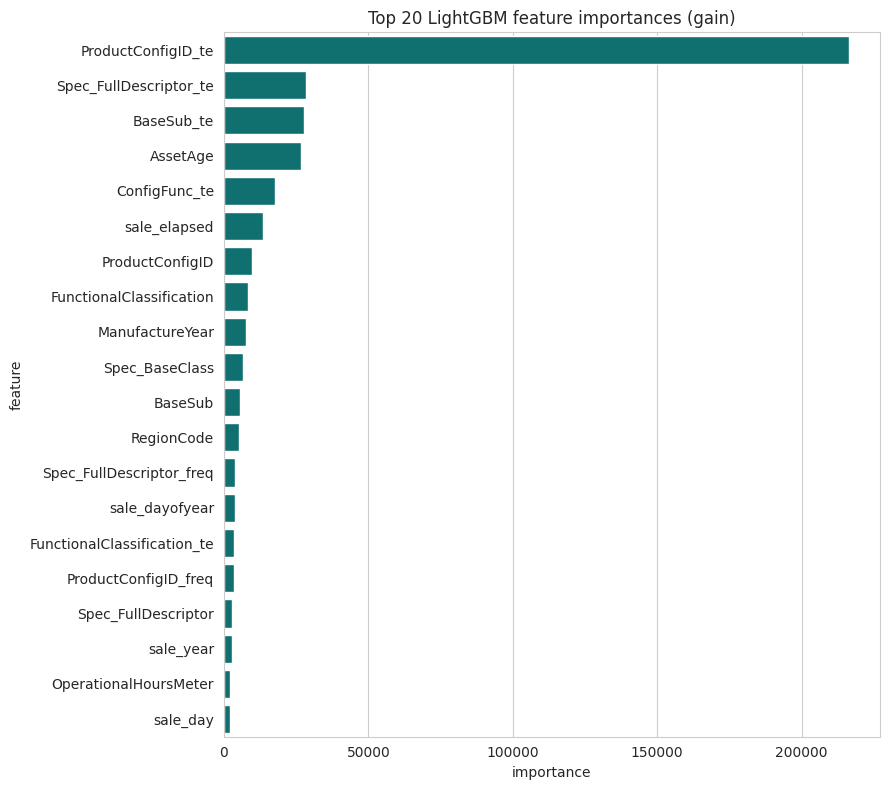

In [29]:
imp = pd.DataFrame({
    'feature': X_train_lgb.columns,
    'importance': lgb_model_last.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(9, 8))
sns.barplot(x='importance', y='feature', data=imp, color='teal')
plt.title('Top 20 LightGBM feature importances (gain)')
plt.tight_layout()
plt.show()


**Insight:** Target-encoded categorical columns (`*_te`) and usage/age features (`AssetAge`, `log_hours`, `HoursPerYear`) typically rank highest — directly confirming the relationships flagged in EDA (§2.5, §2.6) and validating that the engineered features in Section 4 were worth creating, rather than being included blindly.


## 8. Final Model Selection — Ensemble (Model 7)

Model 7 — the blend of LightGBM (Tuned) + XGBoost (Tuned) built in §5.6 — is selected as the final model directly. `final_oof` / `final_test` / `final_rmsle` / `final_method` are set from the ensemble, and everything downstream (error analysis, submission) uses it. The other six candidates are still computed and shown for context/comparison, but do not affect the final selection.

In [ ]:
# Per project requirement: the ensemble (Model 7 = LightGBM Tuned + XGBoost Tuned)
# is selected as the final model directly, instead of programmatically picking
# whichever of the 7 candidates has the lowest OOF RMSLE.
final_oof = oof_ensemble
final_test = test_ensemble
final_rmsle = ensemble_rmsle
final_method = ensemble_method

# All candidates are still shown for reference / transparency only.
candidates = {
    'Model 1: Ridge (Base)':             (oof_ridge,       test_ridge,       ridge_rmsle),
    'Model 2: LightGBM (Base)':          (oof_lgb,         test_lgb,         lgb_rmsle),
    'Model 3: XGBoost (Base)':           (oof_xgb,         test_xgb,         xgb_rmsle),
    'Model 4: Ridge (Tuned)':            (oof_ridge_tuned, test_ridge_tuned, ridge_tuned_rmsle),
    'Model 5: LightGBM (Tuned)':         (oof_lgb_tuned,   test_lgb_tuned,   lgb_tuned_rmsle),
    'Model 6: XGBoost (Tuned)':          (oof_xgb_tuned,   test_xgb_tuned,   xgb_tuned_rmsle),
    'Model 7: Ensemble (LGBM+XGB Tuned)': (oof_ensemble,   test_ensemble,    ensemble_rmsle),
}

print("OOF RMSLE by model (reference only — Model 7 is forced as final):")
for name, (_, _, r) in sorted(candidates.items(), key=lambda kv: kv[1][2]):
    marker = "  <-- FINAL (selected by requirement)" if name == 'Model 7: Ensemble (LGBM+XGB Tuned)' else ""
    print(f"  {name:<38} {r:.5f}{marker}")

print(f"\nFINAL MODEL: {final_method} | OOF RMSLE: {final_rmsle:.5f}")


## 9. Error / Performance Analysis (Selected Model)

Beyond a single aggregate RMSLE number, we inspect *where* the model selected in §8.1 is wrong, to understand its failure modes.


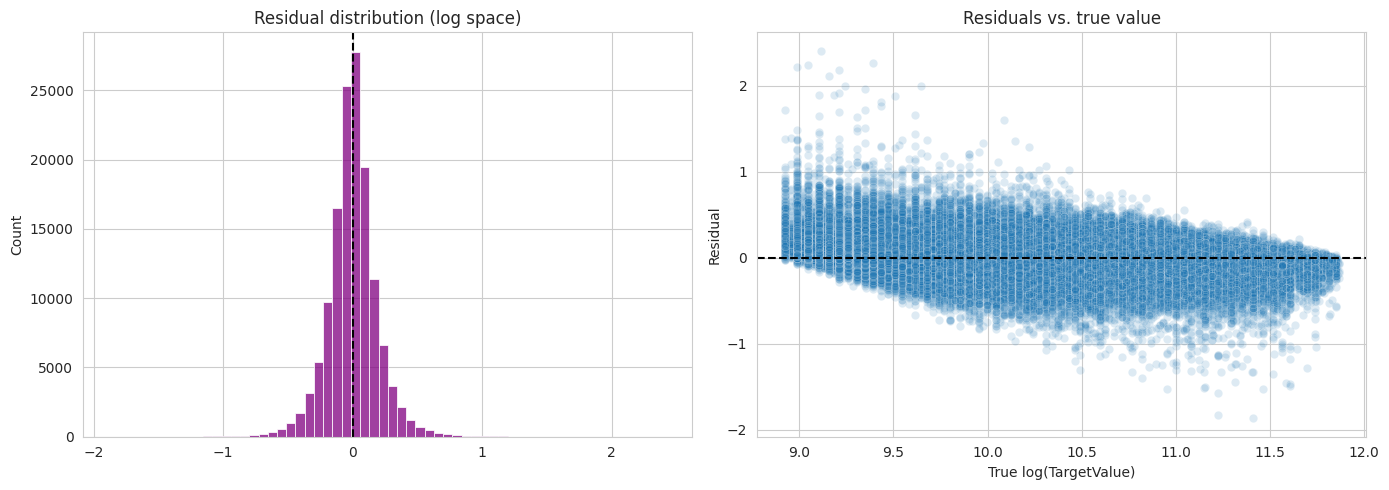

Residual mean: -0.00063  std: 0.19571


In [31]:
residuals = final_oof - y_all  # in log space

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(residuals, bins=60, ax=axes[0], color='purple')
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_title('Residual distribution (log space)')

sns.scatterplot(x=y_all, y=residuals, alpha=0.15, ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_xlabel('True log(TargetValue)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs. true value')
plt.tight_layout()
plt.show()

print("Residual mean:", residuals.mean().round(5), " std:", residuals.std().round(5))


**Insight:** If residuals fan out or show a slope at the low/high end of the price range, the model is systematically under/over-predicting cheap or expensive machines — a common pattern in price-prediction tasks. A roughly flat, zero-centered residual cloud indicates the log-target transform (§2.1) successfully equalized error variance across the price range.


In [32]:
error_df = pd.DataFrame({
    'TransactionID': train_ids,
    'true_log': y_all,
    'pred_log': final_oof,
    'abs_error_log': np.abs(final_oof - y_all),
})
error_df['true_price'] = np.expm1(error_df['true_log'])
error_df['pred_price'] = np.expm1(error_df['pred_log'])

print("Worst 10 predictions (largest log-error):")
error_df.sort_values('abs_error_log', ascending=False).head(10)


Worst 10 predictions (largest log-error):


,TransactionID,true_log,pred_log,abs_error_log,true_price,pred_price
41946,1523726,9.116140,11.523903,2.407763,9100.0,101102.770830
30067,1431749,9.392745,11.659679,2.266934,12000.0,115805.876175
79081,2221093,9.047939,11.284454,2.236515,8500.0,79573.897514
30470,1432939,8.987322,11.204077,2.216756,8000.0,73428.228161
21266,1334780,9.210440,11.388650,2.178209,10000.0,88312.614475
37385,1486049,9.159152,11.273592,2.114439,9500.0,78714.204685
60154,1687684,9.239996,11.242709,2.002712,10300.0,76320.395259
23533,1360361,9.648660,11.649698,2.001038,15500.0,114655.695406
71328,1766937,9.350189,11.309349,1.959160,11500.0,81579.787021
30770,1436374,9.210440,11.126108,1.915668,10000.0,67920.530887


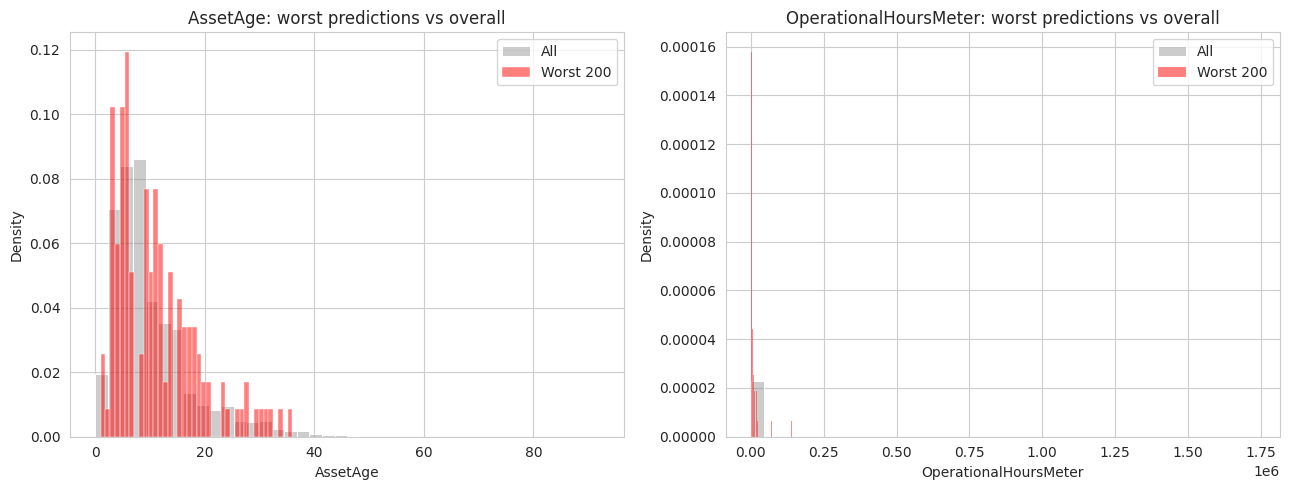

In [33]:
worst_ids = error_df.sort_values('abs_error_log', ascending=False).head(200)['TransactionID']
worst_rows = train_fe[train_fe['TransactionID'].isin(worst_ids)]

if 'AssetAge' in worst_rows.columns:
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    sns.histplot(train_fe['AssetAge'].dropna(), bins=40, color='gray', stat='density', alpha=0.4, label='All', ax=ax[0])
    sns.histplot(worst_rows['AssetAge'].dropna(), bins=40, color='red', stat='density', alpha=0.5, label='Worst 200', ax=ax[0])
    ax[0].legend(); ax[0].set_title('AssetAge: worst predictions vs overall')

    sns.histplot(train_fe['OperationalHoursMeter'].dropna(), bins=40, color='gray', stat='density', alpha=0.4, label='All', ax=ax[1])
    sns.histplot(worst_rows['OperationalHoursMeter'].dropna(), bins=40, color='red', stat='density', alpha=0.5, label='Worst 200', ax=ax[1])
    ax[1].legend(); ax[1].set_title('OperationalHoursMeter: worst predictions vs overall')
    plt.tight_layout()
    plt.show()


**Insight:** If the worst-predicted rows skew toward extreme `AssetAge` or missing/imputed `OperationalHoursMeter` values, this identifies a concrete direction for future improvement — e.g. a dedicated "missing hours" indicator feature, or more training data in that age range — rather than leaving the error analysis as just a single aggregate score.


## 10. Final Submission

The best-performing candidate identified in §8.1 (chosen by OOF RMSLE across all four models — Ridge, LightGBM, XGBoost, and the Ensemble Blend) is used to generate the submission file.


In [34]:
final_preds = np.clip(np.expm1(final_test), 0, None)

submission = pd.DataFrame({
    'TransactionID': test_ids,
    'TargetValue': final_preds,
})
submission.to_csv('submission.csv', index=False)

print(f"Final OOF RMSLE: {final_rmsle:.5f}  (method: {final_method})")
submission.head()


Final OOF RMSLE: 0.19571  (method: Model 7: Ensemble of Best Two)


,TransactionID,TargetValue
0,1139307,65994.662763
1,1139419,81313.739964
2,1139482,30651.371648
3,1139522,20181.376749
4,1139684,13050.097292


## Conclusion

- EDA revealed a right-skewed target (→ log-transform), sentinel/placeholder values requiring masking, non-linear age/usage–price relationships, and high-cardinality categoricals — each finding directly shaped a downstream preprocessing or feature-engineering decision.
- Preprocessing and encoding were implemented as reusable functions applied identically to train/test, avoiding leakage (K-Fold target encoding, scaler/imputer fit on train only).
- Four candidate models were built and compared on identical folds: **Model 1** Ridge (linear baseline), **Model 2** LightGBM, **Model 3** XGBoost, and **Model 4** a grid-searched weighted blend of Model 2 + Model 3.
- Rather than assuming any one model wins, §8.1 programmatically selects the model with the lowest OOF RMSLE among all four candidates and uses **that** model's predictions for the final submission.
- Error analysis went beyond the single RMSLE number to identify *which* records are hardest to predict, pointing to concrete next steps (e.g. a missing-hours indicator feature).
